# KMRF Model - Single Asset Test Notebook


This notebook demonstrates the KMRF (KAMA+MSR+RF) regime prediction pipeline for a single asset:


1. Initialize KMRF model for a specific asset

2. Load pre-computed features and KAMA+MSR labels

3. Adapt 4-regime labels to 3-class KMRF labels

4. Load and combine macroeconomic features

5. Split data into train/validation/test sets

6. (Optional) Feature selection with Boruta

7. Visualize regimes and data


In [33]:
# %pip install -r requirements.txt
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')



import kmrf as kmrf



%matplotlib inline

## 1. Initialize KMRF Model for Specific Asset

In [34]:
# Define asset to analyze
asset_name = 'SPDR S&P 500 ETF'  # SPY
asset_class = 'us_equity'
classification_type = 'adapted'  # 'original' or 'adapted'

# asset_name = 'Gold Futures'
# asset_class = 'commodity'

# Initialize KMRF for this specific asset
kmrf_model = kmrf.KMRF(
    asset_name=asset_name,
    asset_class=asset_class,
    end_date='20190101',
    use_ready_data=True,
    validation_start='2019-04-01',
    validation_end='2019-09-30',
    test_start='2020-01-01',
    random_seed=1010,
    classification_type=classification_type
)

print(f"\n{kmrf_model}")

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: adapted
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 to 2019-09-30
  Test start: 2020-01-01
  Random seed: 1010

KMRF('SPDR S&P 500 ETF', us_equity)


## 2. Load Data and Features

In [35]:
# Load data for this asset
data = kmrf_model.load_data()



# Extract pre-computed features
features = kmrf_model.get_features()



print(f"\nData shape: {data.shape}")
print(f"Features shape: {features.shape}")
print(f"Date range: {features.index[0]} to {features.index[-1]}")


Loading data from: data/ready/us_equity.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 9022
  Columns: 112
  Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (9022, 112)

Data shape: (9022, 112)
Features shape: (9022, 112)
Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00


## 3. Load KAMA+MSR Labels

In [36]:
# Load original 4-regime labels from saved models
original_labels = kmrf_model.load_kama_msr_labels()


LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Model directory: saved_models/KAMA_MSR/us_equity/20190101
Loading from: SPDR S&P 500 ETF_KAMA-MSR_4-regimes.pkl
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6041

  Original 4-regime distribution:
    0 -   LV Bullish:  4560 ( 75.7%)
    1 -   LV Bearish:  1138 ( 18.9%)
    2 -   HV Bullish:    26 (  0.4%)
    3 -   HV Bearish:   299 (  5.0%)


In [37]:
# Adapt to 3-class KMRF labels
adapted_labels = kmrf_model.adapt_regime_labels()


ADAPTING REGIME LABELS FOR SPDR S&P 500 ETF

  Adapted 3-class distribution:
     Bullish ( 1):  4908 ( 81.2%)
       Other ( 0):   312 (  5.2%)
     Bearish (-1):   821 ( 13.6%)


## 4. Prepare Training Data with Train/Val/Test Split



**New Feature:** Data is automatically split into:

- **Training**: All data before 2019-04-01

- **Validation**: 2019-04-01 to 2019-09-30

- **Test**: 2020-01-01 onwards



Set `select_features=True` to use Boruta feature selection (applied only on training data)

In [38]:
# Prepare training data with automatic splitting
# Set select_features=True to use Boruta (may take time)
X_train, y_train = kmrf_model.prepare_training_data(
    # transform_labels=True,
    include_macro=True,
    select_features=False,  # Set to True to use Boruta
    split_data=True  # Automatically creates train/val/test splits
)


PREPARING TRAINING DATA FOR SPDR S&P 500 ETF

Step 1: Technical Features
  Features Shape: (9022, 112)

Step 2: Loading Macroeconomic Data

Loading macroeconomic data from: data/ready/macro_data_all.csv
Aligned macro data to features index
Macro data shape: (9022, 52)
Macro indicators: 52
  Combined shape: (9022, 164)

Step 3: Using Pre-Adapted Labels
  (3-class labels from previous adapt_regime_labels() call)
  Labels Shape: (6041,)

Step 4: Cleaning Features - start when labels exist
  Features date range: 1995-01-04 00:00:00 to 2025-10-24 00:00:00
  Labels date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Dropping 3 features with >50% NaN values
  Features ready across full date range

Step 5: Splitting Data
  Train/Validation/Test Split:
    Training   : Before 2019-04-01
    Validation : 2019-04-01 to 2019-09-30
    Test       : 2020-01-01 to End

  Split sizes:
    Training   : 6041 samples with labels (1995-01-04 to 2018-12-31)
    Validation : 127 samples (features only

## 5. Train Random Forest Model

In [39]:
print("\n" + "="*80)
print("TRAINING RANDOM FOREST MODEL")
print("="*80)

# Train the Random Forest classifier
kmrf_model.fit(kmrf_model.X_train, kmrf_model.y_train)

print("\n✓ Model training complete!")


TRAINING RANDOM FOREST MODEL

TRAINING RANDOM FOREST CLASSIFIER
RF Parameters:
  n_estimators: 220
  max_depth: 13
  min_samples_split: 76
  min_samples_leaf: 95
  max_samples: 0.36
  max_features: 0.25
  min_weight_fraction_leaf: 0.045
  random_state: 1010
  n_jobs: -1

Training samples: 6040
Features: 161
Date range: 1995-01-04 00:00:00 to 2018-12-28 00:00:00

Fitting Random Forest...

TRAINING COMPLETE
Model ready for prediction

✓ Model training complete!


## 6. Generate Predictions on Test Set

In [40]:
print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

# Generate predictions for the test set
test_predictions = kmrf_model.predict(kmrf_model.X_test, return_proba=True)

print(f"\nTest predictions generated:")
print(f"  Shape: {test_predictions.shape}")
print(f"  Date range: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")

# Show sample predictions
print(f"\nSample predictions (first 10 rows):")
print(test_predictions.head(10).round(4))

# Get predicted regimes (highest probability class)
predicted_regimes = kmrf_model.predict(kmrf_model.X_test, return_proba=False)
predicted_regimes_series = pd.Series(predicted_regimes, index=test_predictions.index)

if classification_type == 'original':
    regime_names = {
        0: 'LV Bullish',
        1: 'LV Bearish',
        2: 'HV Bullish',
        3: 'HV Bearish'
    }
else: # adapted
    regime_names = {
        -1: 'Bearish',
         0: 'Neutral',
         1: 'Bullish'
    }
print(f"\nPredicted regime distribution:")
for regime, name in regime_names.items():
    count = (predicted_regimes_series == regime).sum()
    pct = (count / len(predicted_regimes_series)) * 100
    print(f"  {name:>8} ({regime:>2}): {count:>5} ({pct:>5.1f}%)")


GENERATING PREDICTIONS ON TEST SET

Generating predictions...
Generated probability predictions: (1463, 3)

Test predictions generated:
  Shape: (1463, 3)
  Date range: 2020-01-02 to 2025-10-24

Sample predictions (first 10 rows):
            P(Bearish)  P(Other)  P(Bullish)
date                                        
2020-01-02      0.0060    0.0794      0.9146
2020-01-03      0.0061    0.0782      0.9157
2020-01-06      0.0060    0.0788      0.9152
2020-01-07      0.0060    0.0797      0.9143
2020-01-08      0.0060    0.0788      0.9152
2020-01-09      0.0060    0.0794      0.9146
2020-01-10      0.0058    0.0754      0.9188
2020-01-13      0.0052    0.0714      0.9234
2020-01-14      0.0050    0.0692      0.9258
2020-01-15      0.0051    0.0693      0.9256

Generating predictions...
Generated class predictions: 1463

Predicted regime distribution:
   Bearish (-1):     0 (  0.0%)
   Neutral ( 0):   467 ( 31.9%)
   Bullish ( 1):   996 ( 68.1%)


## 7. Visualize Predicted Regimes on SPY Price

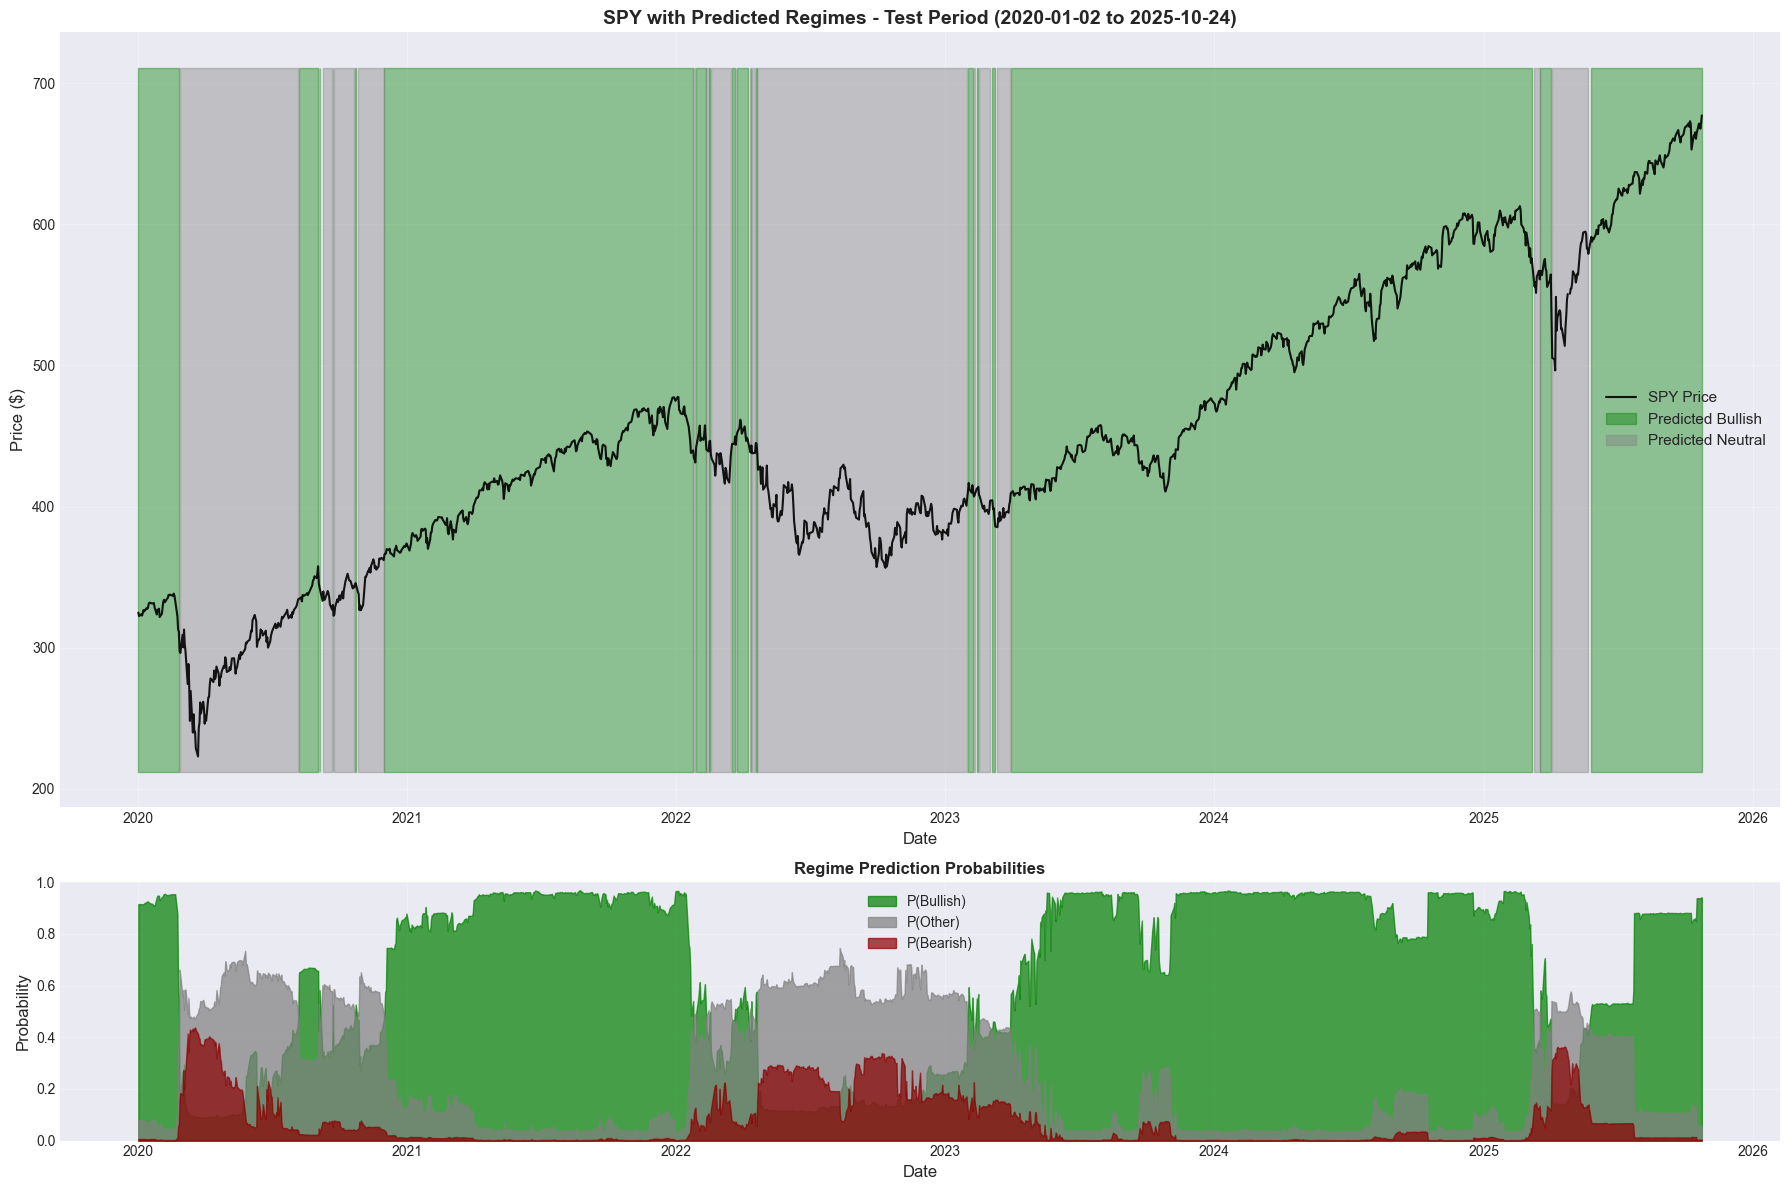


✓ Regime visualization complete!

PREDICTION SUMMARY FOR SPY
Test Period: 2020-01-02 to 2025-10-24
Total Trading Days: 1463

Price Performance:
  Start Price: $324.87
  End Price: $677.25
  Total Return: 108.47%

Regime Prediction Statistics:
   Bearish:   0 days (  0.0%) | Avg Prob: 0.075


KeyError: 'P(Neutral)'

In [41]:
# Get full price data and filter for test period
spy_price_full = kmrf_model.features['close']
spy_price_test = spy_price_full.loc[test_predictions.index]

if spy_price_test is not None:
    # Create comprehensive visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), height_ratios=[3, 1])
    
    # === Price Plot with Regime Overlays ===
    # Plot SPY price
    ax1.plot(spy_price_test.index, spy_price_test, color='black', linewidth=1.5, 
             alpha=0.9, label='SPY Price', zorder=3)
    
    # Define colors and labels for regimes based on classification type
    if classification_type == 'original':
        colors = {0: 'green', 1: 'lightblue', 2: 'yellow', 3: 'darkred'}
        labels_dict = {0: 'LV_Bull', 1: 'LV_Bear', 2: 'HV_Bull', 3: 'HV_Bear'}
    else:
        colors = {1: 'green', 0: 'grey', -1: 'darkred'}
        labels_dict = {1: 'Bullish', 0: 'Neutral', -1: 'Bearish'}
    
    
    # Shade regime periods
    for regime in labels_dict:
        mask = predicted_regimes_series == regime
        if mask.any():
            ax1.fill_between(
                spy_price_test.index,
                spy_price_test.min() * 0.95,
                spy_price_test.max() * 1.05,
                where=mask,
                alpha=0.4,
                color=colors[regime],
                label=f'Predicted {labels_dict[regime]}',
                zorder=1
            )
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title(f'SPY with Predicted Regimes - Test Period ({test_predictions.index[0].date()} to {test_predictions.index[-1].date()})', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, zorder=2)
    
    # === Regime Probabilities ===
    # Plot regime probabilities
    # Handle different regime types based on classification
    if classification_type == 'original':
        # Original 4-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bull)'],
                     alpha=0.7, color='green', label='P(LV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bear)'],
                     alpha=0.7, color='lightblue', label='P(LV Bearish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bull)'],
                     alpha=0.7, color='yellow', label='P(HV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bear)'],
                     alpha=0.7, color='darkred', label='P(HV Bearish)')
    else:
        # Adapted 3-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bullish)'],
                     alpha=0.7, color='green', label='P(Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Other)'],
                     alpha=0.7, color='gray', label='P(Other)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bearish)'],
                     alpha=0.7, color='darkred', label='P(Bearish)')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Regime Prediction Probabilities', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Regime visualization complete!")
    
    # === Summary Statistics ===
    print(f"\n" + "="*60)
    print(f"PREDICTION SUMMARY FOR SPY")
    print(f"="*60)
    print(f"Test Period: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")
    print(f"Total Trading Days: {len(test_predictions)}")
    
    # Price performance during test period
    price_start = spy_price_test.iloc[0]
    price_end = spy_price_test.iloc[-1]
    total_return = (price_end - price_start) / price_start * 100
    
    print(f"\nPrice Performance:")
    print(f"  Start Price: ${price_start:.2f}")
    print(f"  End Price: ${price_end:.2f}")
    print(f"  Total Return: {total_return:.2f}%")
    
    # Regime statistics
    print(f"\nRegime Prediction Statistics:")
    for regime, name in regime_names.items():
        count = (predicted_regimes_series == regime).sum()
        pct = (count / len(predicted_regimes_series)) * 100
        avg_prob = test_predictions['P(' + labels_dict[regime] + ')'].mean()
        print(f"  {name:>8}: {count:>3} days ({pct:>5.1f}%) | Avg Prob: {avg_prob:.3f}")
    
    # High confidence predictions
    high_confidence = test_predictions.max(axis=1) > 0.7
    print(f"\nHigh Confidence Predictions (>70%): {high_confidence.sum()} days ({high_confidence.mean()*100:.1f}%)")
    
    print(f"\nNote: According to the contrarian strategy:")
    print(f"  - High P(Bullish) → SHORT signal (overbought)")
    print(f"  - High P(Bearish) → LONG signal (oversold)")
    print(f"  - High P(Other) → CLOSE position")

else:
    print("Error: Could not find SPY price data for visualization")

print("\n" + "="*80)
print("KMRF MODEL TRAINING AND PREDICTION COMPLETE")
print("="*80)

In [ ]:
test_predictions

,P(LV_Bull),P(LV_Bear),P(HV_Bull),P(HV_Bear)
date,,,,
2020-01-02,0.845740,0.030228,0.121423,0.002608
2020-01-03,0.842235,0.028845,0.126578,0.002342
2020-01-06,0.846218,0.029751,0.121423,0.002608
2020-01-07,0.846101,0.029868,0.121423,0.002608
2020-01-08,0.860443,0.028332,0.109169,0.002056
...,...,...,...,...
2025-10-20,0.709199,0.032819,0.253353,0.004628
2025-10-21,0.764350,0.032869,0.199964,0.002817
2025-10-22,0.762938,0.034050,0.199964,0.003048
